<a href="https://colab.research.google.com/github/Ketan19-hue/KETAN_2026D0031101002/blob/main/creditcardandfrauddetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

(10000, 8)
amount         0
time_of_day    0
v1             0
v2             0
v3             0
v4             0
v5             0
is_fraud       0
dtype: int64
is_fraud
0    9948
1      52
Name: count, dtype: int64
is_fraud
0    99.48
1     0.52
Name: proportion, dtype: float64


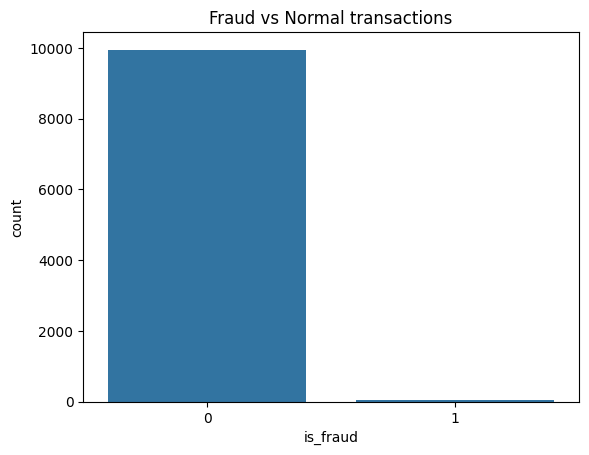

(10000, 7) (10000,)
Train size: 8000
Test size: 2000
Fraud cases in train: 42
Fraud cases in test: 10
Before SMOTE: {0: 7958, 1: 42}
After SMOTE: {0: 7958, 1: 7958}
SVM ROC-AUC: 0.761
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      1990
           1       0.02      0.30      0.04        10

    accuracy                           0.93      2000
   macro avg       0.51      0.62      0.50      2000
weighted avg       0.99      0.93      0.96      2000

XGBoost ROC-AUC: 0.721
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1990
           1       0.04      0.30      0.08        10

    accuracy                           0.96      2000
   macro avg       0.52      0.63      0.53      2000
weighted avg       0.99      0.96      0.98      2000



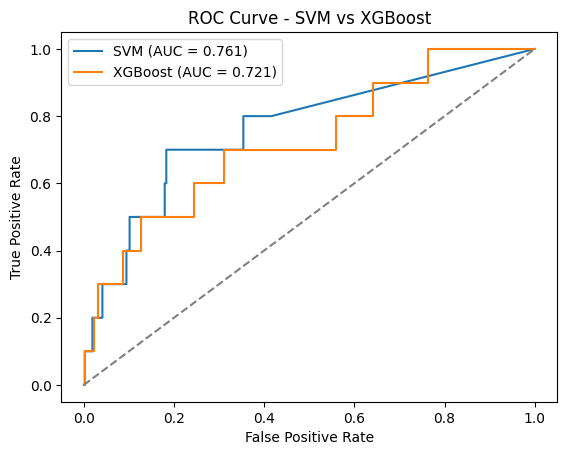

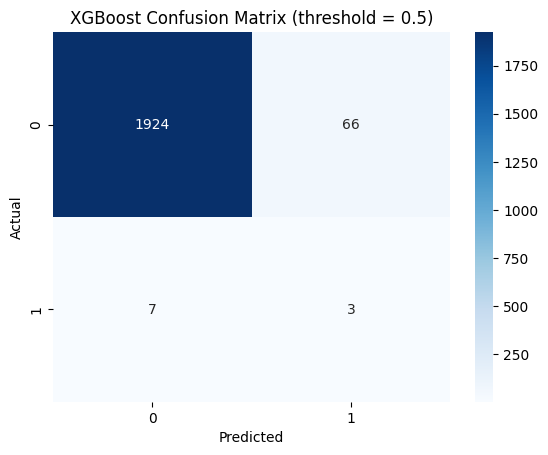

Confusion matrix at threshold = 0.3:
[[1881  109]
 [   7    3]]

False Negatives at 0.5 threshold: 7
False Negatives at 0.3 threshold: 7

False Positives at 0.5 threshold: 66
False Positives at 0.3 threshold: 109
       Feature  Importance
2           v1    0.309948
3           v2    0.221250
0       amount    0.148704
1  time_of_day    0.085213
5           v4    0.084215
6           v5    0.075434
4           v3    0.075236


/tmp/ipykernel_1568/1693136364.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


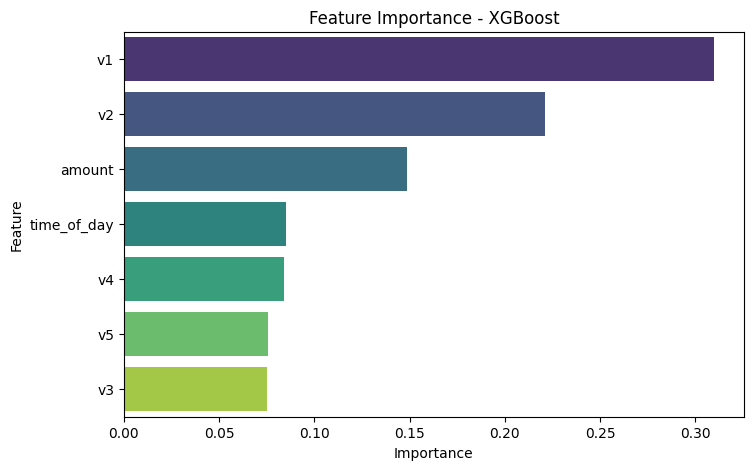

In [ ]:
# STEP - 1 INSTALLING AND IMPORTING LIBRARIES
# !pip install xgboost imbalanced-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, precision_recall_curve
)

# STEP - 2 CREATING THE TRANSACTION DATASET

np.random.seed(42)
n = 10000

amount = np.random.exponential(scale=60, size=n).round(2)
time_of_day = np.random.uniform(0, 24, n).round(2)

# some fake anonymized features, similar to V1, V2... in the real dataset
v1 = np.random.normal(0, 1, n)
v2 = np.random.normal(0, 1, n)
v3 = np.random.normal(0, 1, n)
v4 = np.random.normal(0, 1, n)
v5 = np.random.normal(0, 1, n)

# making fraud depend a bit on these features so the data is not totally random
fraud_score = (0.02*amount - 0.05*time_of_day + 1.5*v1 - 1.2*v2 + 0.8*v3 - 6)
fraud_prob = 1 / (1 + np.exp(-fraud_score))

# forcing fraud to stay rare (around 1.5%) like real data
fraud_prob = fraud_prob * 0.15
is_fraud = np.random.binomial(1, fraud_prob)

data = pd.DataFrame({
    'amount': amount,
    'time_of_day': time_of_day,
    'v1': v1, 'v2': v2, 'v3': v3, 'v4': v4, 'v5': v5,
    'is_fraud': is_fraud
})

data.head()

# STEP - 3 BASIC DATA CHECKING ( EDA - EXPLORATORY DATA ANALYSIS)

print(data.shape)
print(data.isnull().sum())
data.describe()

print(data['is_fraud'].value_counts())
print(data['is_fraud'].value_counts(normalize=True) * 100)

sns.countplot(x='is_fraud', data=data)
plt.title('Fraud vs Normal transactions')
plt.show()

# STEP - 4 SPLITTING INTO X AND Y

X = data.drop('is_fraud', axis=1)
y = data['is_fraud']

print(X.shape, y.shape)

# STEP - 5 Train test split (80-20)
# I used stratify-y here so that both train and test sets get a similar percentage of fraud cases,
# otherwise the test set might end up with very few or zero fraud cases.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Fraud cases in train:", y_train.sum())
print("Fraud cases in test:", y_test.sum())

# STEP - 6 SCALING THE FEATURES

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# STEP - 7 APPLYING SMOTE ON TRAINING DATA

print("Before SMOTE:", y_train.value_counts().to_dict())

# STEP - 8 BASELINE MODEL - SVM

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print("After SMOTE:", pd.Series(y_train_sm).value_counts().to_dict())

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_sm, y_train_sm)

svm_pred = svm_model.predict(X_test_sc)
svm_prob = svm_model.predict_proba(X_test_sc)[:, 1]

svm_auc = roc_auc_score(y_test, svm_prob)
print("SVM ROC-AUC:", round(svm_auc, 3))
print(classification_report(y_test, svm_pred))

# STEP - 9 TRAINING XGBOOST MODEL

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train_sm, y_train_sm)

xgb_pred = xgb_model.predict(X_test_sc)
xgb_prob = xgb_model.predict_proba(X_test_sc)[:, 1]

xgb_auc = roc_auc_score(y_test, xgb_prob)
print("XGBoost ROC-AUC:", round(xgb_auc, 3))
print(classification_report(y_test, xgb_pred))

# STEP -10 COMPARING SVM VS XGBOOST USING ROC CURVE

fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.plot(fpr_svm, tpr_svm, label='SVM (AUC = %0.3f)' % svm_auc)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.3f)' % xgb_auc)
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM vs XGBoost')
plt.legend()
plt.show()

# STEP - 11 CONFUSION MATRIX FOR XGBOOST

cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix (threshold = 0.5)')
plt.show()

# STEP - 12 TUNING THE DECISION THRESOLD

threshold = 0.3
xgb_pred_lower = (xgb_prob >= threshold).astype(int)

cm_lower = confusion_matrix(y_test, xgb_pred_lower)
print(f"Confusion matrix at threshold = {threshold}:")
print(cm_lower)

print("\nFalse Negatives at 0.5 threshold:", cm[1][0])
print("False Negatives at 0.3 threshold:", cm_lower[1][0])
print("\nFalse Positives at 0.5 threshold:", cm[0][1])
print("False Positives at 0.3 threshold:", cm_lower[0][1])

# STEP - 13 FEATURE IMPORTANCE FROM XGBOOST

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Feature Importance - XGBoost')
plt.show()

